In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    ExtraTreesClassifier,
)
import xgboost as xgb
from catboost import CatBoostClassifier
from sklearn.base import BaseEstimator
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
)

import joblib
class SklearnCatBoost(CatBoostClassifier, BaseEstimator):
    pass
from sklearn.model_selection import RandomizedSearchCV
from lightgbm import LGBMClassifier
import warnings
from sklearn.pipeline import Pipeline
import optuna

/Users/yagiz/Desktop/CustomerChurn/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv('../data/Customer-Churn.csv')

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
df.drop("customerID",axis=1,inplace=True)

In [7]:
df["MultipleLines"].value_counts()

MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

In [8]:

temp_charges = pd.to_numeric(df['TotalCharges'], errors='coerce')

hatali_satirlar = df[temp_charges.isnull()]


print(f"Toplam hatalı satır sayısı: {len(hatali_satirlar)}")
print(hatali_satirlar[['TotalCharges']])


Toplam hatalı satır sayısı: 11
     TotalCharges
488              
753              
936              
1082             
1340             
3331             
3826             
4380             
5218             
6670             
6754             


In [9]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df["TotalCharges"].median(), inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


/var/folders/43/j4vtpg657ys993dvz400r9sw0000gn/T/ipykernel_13662/2329064715.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df["TotalCharges"].median(), inplace=True)


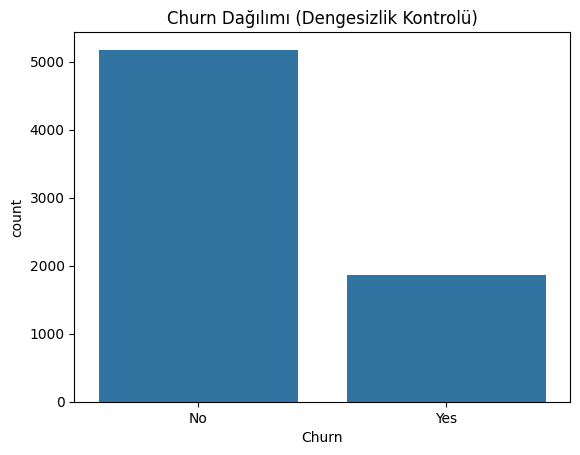

In [10]:
sns.countplot(x='Churn', data=df)
plt.title('Churn Dağılımı (Dengesizlik Kontrolü)')
plt.show()

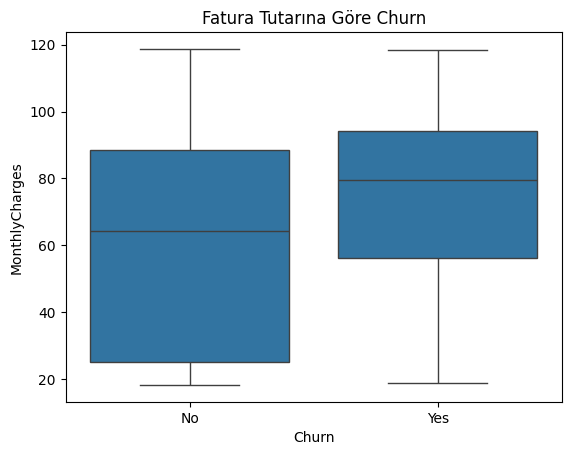

In [11]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Fatura Tutarına Göre Churn')
plt.show()

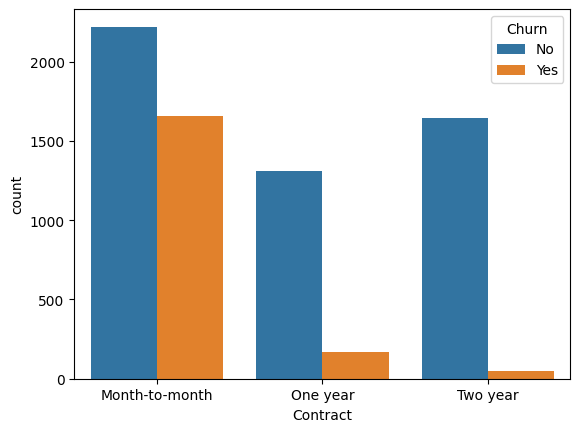

In [12]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.show()

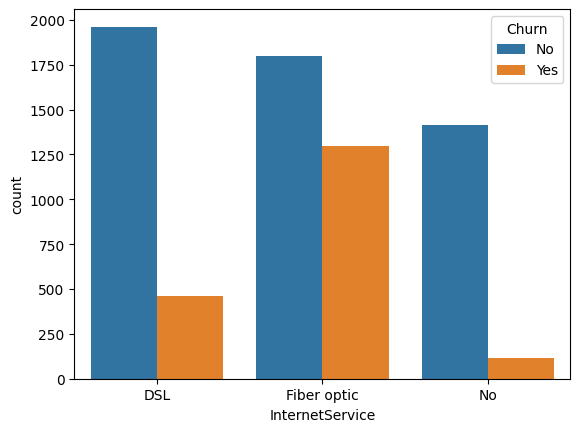

In [13]:
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.show()

In [14]:
from sklearn.preprocessing import LabelEncoder


le = LabelEncoder()
y = le.fit_transform(df["Churn"]) 

X = df.drop("Churn", axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
categorical_features = ["gender","Partner","Dependents","PhoneService","MultipleLines","InternetService","OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies","PaperlessBilling","PaymentMethod"]

In [16]:
preprocessor = ColumnTransformer(
    transformers=[
        ("1",OneHotEncoder(handle_unknown="ignore"),categorical_features),
        ("2",OrdinalEncoder(),["Contract"])
    ],
    remainder="passthrough"
)



In [ ]:
pipelines = {
    "Rf": Pipeline([
        ("preprocessor",preprocessor),
        ("rf",RandomForestClassifier(n_estimators=100,random_state=42))
    ]),
    "catboost":Pipeline([
        ("preprocessor",preprocessor),
      
        ("catboost",SklearnCatBoost(random_state=42,verbose=0))
    
    ]),
    "lgbm": Pipeline([
        ("preprocessor",preprocessor),
        ("lgbm",lgb.LGBMClassifier(n_estimators=100,random_state=42))
    ]),

    
}

In [18]:
for name,pipeline in pipelines.items():
    try:
        pipeline.fit(X_train,y_train)
        y_pred = pipeline.predict(X_test)
        print(f"{name} modeli performansı:")
        print(f"Accuracy: {accuracy_score(y_test,y_pred)}")
        print(f"classification report:\n{classification_report(y_test, y_pred, target_names=['No','Yes'])}")
        print(f"F1 Score: {f1_score(y_test, y_pred, pos_label=1)}")
        print(f"Precision: {precision_score(y_test, y_pred, pos_label=1)}")
        print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred)}")
        

    except Exception as e:
        print(f"{name} modeli hata verdi: {e}")
    print("-------------------------------")

Rf modeli performansı:
Accuracy: 0.794889992902768
classification report:
              precision    recall  f1-score   support

          No       0.82      0.92      0.87      1036
         Yes       0.67      0.45      0.54       373

    accuracy                           0.79      1409
   macro avg       0.75      0.68      0.70      1409
weighted avg       0.78      0.79      0.78      1409

F1 Score: 0.536115569823435
Precision: 0.668
ROC AUC Score: 0.6838026747544175
-------------------------------
catboost modeli performansı:
Accuracy: 0.8019872249822569
classification report:
              precision    recall  f1-score   support

          No       0.84      0.90      0.87      1036
         Yes       0.66      0.52      0.58       373

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409

F1 Score: 0.5804511278195489
Precision: 0.660958904109589
ROC AUC Score: 0.71093

In [19]:
def objective(trial):
    param = {
        'iterations': trial.suggest_int('iterations', 200, 1000),
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10, log=True),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'random_strength': trial.suggest_float('random_strength', 1e-9, 10, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
        'auto_class_weights': 'Balanced',
        'verbose': 0,
        'random_state': 42,
        'allow_writing_files': False 
    }

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("catboost", CatBoostClassifier(**param))
    ])

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return f1_score(y_test, y_pred, pos_label=1)

print("Optuna Optimizasyonu Başlıyor...")
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

print("\n------------------------------------------------")
print("En İyi Parametreler:", study.best_params)
print("En İyi F1 Skoru:", study.best_value)
print("------------------------------------------------\n")

best_params = study.best_params
best_params['auto_class_weights'] = 'Balanced'
best_params['verbose'] = 0
best_params['random_state'] = 42

final_model = Pipeline([
    ("preprocessor", preprocessor),
    ("catboost", CatBoostClassifier(**best_params))
])

final_model.fit(X_train, y_train)
y_pred_final = final_model.predict(X_test)
y_pred_proba = final_model.predict_proba(X_test)[:, 1] 

print(">>> FINAL OPTIMIZED CATBOOST PERFORMANSI <<<")

print(classification_report(y_test, y_pred_final, target_names=['No', 'Yes']))

print(f"Accuracy: {accuracy_score(y_test, y_pred_final):.4f}")
print(f"F1 Score (Yes): {f1_score(y_test, y_pred_final, pos_label=1):.4f}")
print(f"Precision (Yes): {precision_score(y_test, y_pred_final, pos_label=1):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

[I 2025-12-13 18:39:28,052] A new study created in memory with name: no-name-529a146a-9425-456d-ae98-76fa26bac1b5


Optuna Optimizasyonu Başlıyor...


[I 2025-12-13 18:39:29,143] Trial 0 finished with value: 0.6484118291347207 and parameters: {'iterations': 778, 'depth': 6, 'learning_rate': 0.011113576397461805, 'l2_leaf_reg': 0.002462172803182136, 'border_count': 249, 'random_strength': 1.9553689037233306e-08, 'bagging_temperature': 0.11573043772541858}. Best is trial 0 with value: 0.6484118291347207.
[I 2025-12-13 18:39:29,870] Trial 1 finished with value: 0.6414686825053996 and parameters: {'iterations': 688, 'depth': 5, 'learning_rate': 0.018729433398919564, 'l2_leaf_reg': 0.017517271205830822, 'border_count': 70, 'random_strength': 0.014224311260918623, 'bagging_temperature': 0.9129107494242783}. Best is trial 0 with value: 0.6484118291347207.
[I 2025-12-13 18:39:30,673] Trial 2 finished with value: 0.64340239912759 and parameters: {'iterations': 522, 'depth': 6, 'learning_rate': 0.022589629237546562, 'l2_leaf_reg': 0.8285596358021124, 'border_count': 130, 'random_strength': 1.500614174302317e-08, 'bagging_temperature': 0.855627


------------------------------------------------
En İyi Parametreler: {'iterations': 542, 'depth': 6, 'learning_rate': 0.016792622688329033, 'l2_leaf_reg': 8.791560883236505, 'border_count': 103, 'random_strength': 1.2374631471007065e-05, 'bagging_temperature': 0.5297957464221681}
En İyi F1 Skoru: 0.6489925768822906
------------------------------------------------

>>> FINAL OPTIMIZED CATBOOST PERFORMANSI <<<
              precision    recall  f1-score   support

          No       0.92      0.75      0.82      1036
         Yes       0.54      0.82      0.65       373

    accuracy                           0.77      1409
   macro avg       0.73      0.78      0.74      1409
weighted avg       0.82      0.77      0.78      1409

Accuracy: 0.7651
F1 Score (Yes): 0.6490
Precision (Yes): 0.5368
ROC AUC Score: 0.8600


In [ ]:
import os

model_path = '../backend/final_model.pkl'


if os.path.exists(model_path):
    os.remove(model_path)
    


joblib.dump(final_model, model_path, compress=3)
print(f"✅Optimized model başarıyla kaydedildi: {model_path}")
print(f" Dosya boyutu: {os.path.getsize(model_path) / 1024:.2f} KB")


y_pred = final_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

🗑️  Eski model silindi
✅ Optimized model başarıyla kaydedildi: ../backend/final_model.pkl
📦 Dosya boyutu: 264.78 KB
✅ Test Accuracy: 0.7651


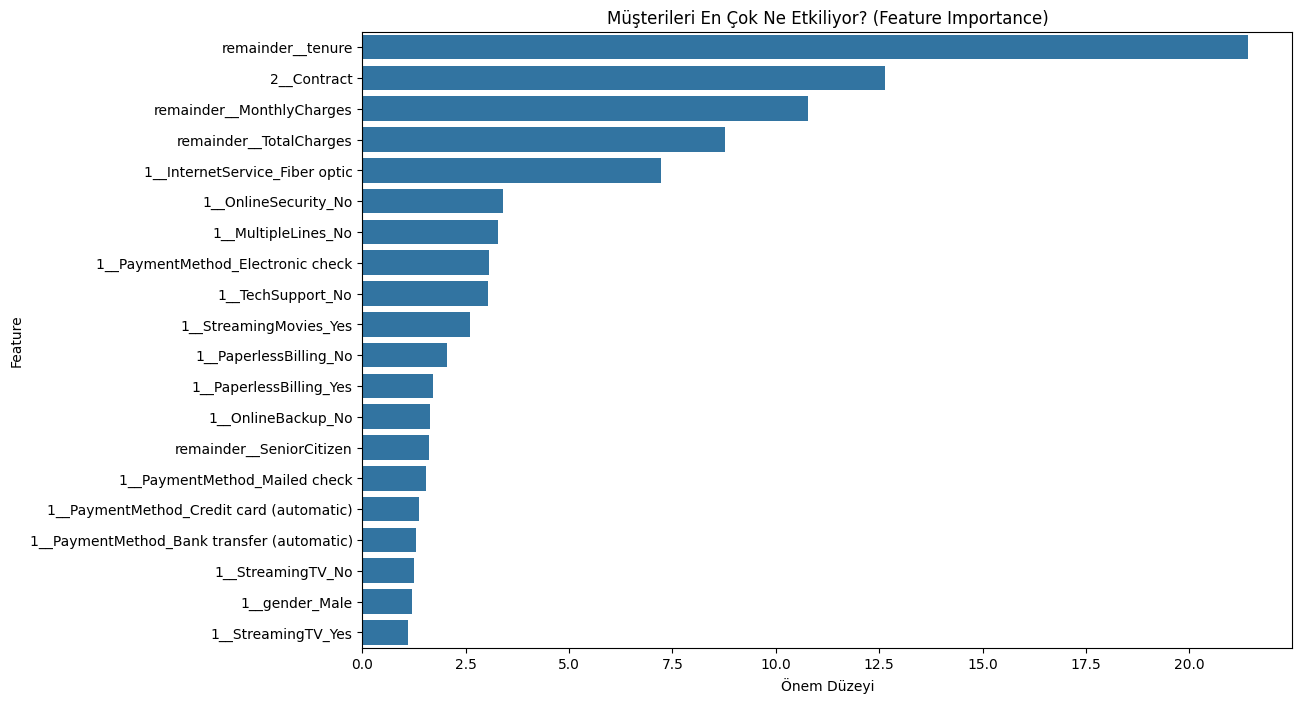

In [ ]:
catboost_model = final_model.named_steps['catboost']
preprocessor = final_model.named_steps['preprocessor']

feature_names = preprocessor.get_feature_names_out()

importances = catboost_model.get_feature_importance()

feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(20)) # İlk 20 özellik
plt.title('Müşterileri En Çok Ne Etkiliyor? (Feature Importance)')
plt.xlabel('Önem Düzeyi')
plt.show()